In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  
import numpy as np

dataset = pd.read_csv("dataset_hdbscan_clusters_5.csv")
print(dataset)

      Rank                 Player Nationality Position  Age  Birth_Year  \
0      625        Aaron Cresswell     eng ENG       DF   34        1989   
1     2744      Aaron Wan-Bissaka      cd COD       DF   26        1997   
2     1638           Aarón Martín      es ESP       DF   27        1997   
3     2534           Abakar Sylla      ci CIV       DF   21        2002   
4     2423          Abdallah Sima      sn SEN    FW,MF   23        2001   
...    ...                    ...         ...      ...  ...         ...   
1701  2630            Óscar Trejo      ar ARG       MF   36        1988   
1702  2660         Óscar Valentín      es ESP       MF   29        1994   
1703    62             Ümit Akdag      ro ROU       DF   20        2003   
1704  1265  Þórir Jóhann Helgason      is ISL       MF   23        2000   
1705  1098         İlkay Gündoğan      de GER       MF   33        1990   

      Matches_Played  Games_Started  Minutes  X90s_Played  ...  \
0                 18             

In [2]:
print(dataset.columns)

Index(['Rank', 'Player', 'Nationality', 'Position', 'Age', 'Birth_Year',
       'Matches_Played', 'Games_Started', 'Minutes', 'X90s_Played',
       'Goals_Per_90', 'Assists_Per_90', 'Goals_Plus_Assists_Per_90',
       'Non_Penalty_Goals_Per_90', 'Non_Penalty_Goals_Plus_Assists_Per_90',
       'Expected_Goals_Per_90', 'Exp_Assisted_Goals_Per_90',
       'Exp_Goals_Plus_Exp_Assists_Per_90', 'Non_Penalty_xG_Per_90',
       'Non_Penalty_xG_Plus_Exp_Assists_Per_90', 'Progressive_Carries_Per_90',
       'Progressive_Passes_Per_90', 'Progressive_Passes_Received_Per_90',
       'Yellow_Cards_Per_90', 'Red_Cards_Per_90', 'Penalties_Attempted_Per_90',
       'Tackles_Per_90', 'Tackles_Won_Per_90', 'Tackles_Def_3rd_Per_90',
       'Tackles_Mid_3rd_Per_90', 'Tackles_Att_3rd_Per_90',
       'Dribblers_Tackled_Per_90', 'Dribbles_Challenged_Per_90',
       'Challenges_Lost_Per_90', 'Blocks_Per_90', 'Shots_Blocked_Per_90',
       'Passes_Blocked_Per_90', 'Interceptions_Per_90',
       'Tackles_Plus_In

In [2]:
#drop nans values
check_nans = dataset.isna().sum().sum()
print(f"Nans found: {check_nans}")

print(f"{len(dataset)} players")

Nans found: 0
1706 players


In [3]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

features = [
    #attacking
    'Non_Penalty_Goals_Per_90',                
    'Expected_Goals_Per_90',  
    #creating
    'Assists_Per_90',              
    'Exp_Assisted_Goals_Per_90',   
    'Progressive_Passes_Per_90',       
    'Progressive_Carries_Per_90',      
    'Progressive_Passes_Received_Per_90', 
    #defensive
    'Tackles_Won_Per_90',          
    'Interceptions_Per_90',        
    'Passes_Blocked_Per_90',               
    'Clearances_Per_90',  
    'Shots_Blocked_Per_90',
    'Dribblers_Tackled_Per_90',
    'Dribbles_Challenged_Per_90',
    #reliability 
    'Errors_Leading_To_Shot_Per_90',
    'Challenges_Lost_Per_90',
    'Age']


In [5]:
#split and train data
#scaling and encoding

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, PredefinedSplit


#remove noise/hybrid players for classification
dataset_1 = dataset[dataset['tactical_roles_hdbscan'] != -1].copy()

# features and target
X = dataset_1[features].values
y = dataset_1['tactical_role_name'].values

position_encoder = LabelEncoder()
y_encoded = position_encoder.fit_transform(y)

#1st split: 15% test (100-85)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y_encoded, test_size=0.15, random_state=25, stratify=y_encoded)

#2nd split: 70% train, 15% val (15/85 = 0.1765)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.176, random_state=25, stratify=y_train_val)

#scaling only on training data and use the same scaling on test data and validation data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

#combine train and val set
X_combined = np.concatenate([X_train_scaled, X_val_scaled])
y_combined = np.concatenate([y_train, y_val])

# -1 = train split, 0 = validation split
split_index = [-1] * len(X_train_scaled) + [0] * len(X_val_scaled)
pds = PredefinedSplit(test_fold=split_index)

In [5]:
print(dataset_1.shape)

(1271, 55)


In [6]:
print("X_train shape:", X_train_scaled.shape)
print("X_val shape:  ", X_val_scaled.shape)
print("X_test shape: ", X_test_scaled.shape)

X_train shape: (889, 17)
X_val shape:   (191, 17)
X_test shape:  (191, 17)


In [7]:
print(np.unique(y_combined))

[0 1 2 3 4 5 6]


In [10]:
for i, class_name in enumerate(position_encoder.classes_):
    print(f"{i} — {class_name}")

0 — Ball Winners / Enforcers / Press Specialists
1 — Box-box / All rounder
2 — Creators / Deep Lying Playmakers / Tempo Dictators
3 — Fullback / Wingbacks / Overlappers
4 — Goals Scorers / Finishers
5 — Traditional Centre Backs / Blockers 
6 — Wingers / Ball Carriers


In [ ]:
#supervised machine learning models

In [ ]:
#Logistic Regression 

In [11]:
#logistic regression gridsearch for best params

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


lr_param_grid = {
    'C': [0.01, 0.1, 1],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [100, 200, 500]
}

lr_grid = GridSearchCV(
    estimator=LogisticRegression(random_state=25),
    param_grid=lr_param_grid,
    cv=pds,                    
    scoring='f1_macro',
    return_train_score=True)

lr_grid.fit(X_combined, y_combined)

print(f"Best LR Params: {lr_grid.best_params_}")
print(f"Training Mean F1 score: {lr_grid.cv_results_['mean_train_score'][lr_grid.best_index_]*100:.2f}")
print(f"Validation Mean F1 score: {lr_grid.cv_results_['mean_test_score'][lr_grid.best_index_]*100:.2f}")





Best LR Params: {'C': 1, 'max_iter': 100, 'solver': 'lbfgs'}
Training Mean F1 score: 95.69
Validation Mean F1 score: 91.88


In [12]:
#Logistic Regression model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

lr_model = LogisticRegression(
    C=1,               
    solver='lbfgs',      
    max_iter=100,
    random_state=25)

lr_model.fit(X_combined, y_combined)
y_pred_lr = lr_model.predict(X_test_scaled)


lr_score = lr_model.score(X_test_scaled, y_test)
lr_precision = precision_score(y_test, y_pred_lr, average='macro')
lr_recall = recall_score(y_test, y_pred_lr, average='macro')
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')

print(f"Logistic Regression Accuracy: {lr_score:.2%}")
print(f"Logistic Regression Precision: {lr_precision:.2%}")
print(f"Logistic Regression Recall:    {lr_recall:.2%}")
print(f"Logistic Regression F1-Score:  {lr_f1:.2%}")

Logistic Regression Accuracy: 90.58%
Logistic Regression Precision: 90.53%
Logistic Regression Recall:    90.71%
Logistic Regression F1-Score:  90.57%


In [ ]:
#Support Vector Machines (SVM) 

In [13]:
#SVM girdsearch for best params

from sklearn.svm import SVC

svm_param_grid = {
    'C': [0.01, 0.1, 1], 
    'gamma': [0.01, 0.02, 0.03, 0.04, 0.05],
    'kernel':['rbf', 'linear', 'poly']}

svm_grid = GridSearchCV(
    estimator=SVC(random_state=25),
    param_grid=svm_param_grid,
    cv=pds, 
    scoring='f1_macro',
    return_train_score=True)

svm_grid.fit(X_combined, y_combined)

print(f"Best SVM Params from gridsearch: {svm_grid.best_params_}")
print(f"SVM_Training Mean F1 score: {svm_grid.cv_results_['mean_train_score'][svm_grid.best_index_]*100:.2f}")
print(f"SVM_Validation Mean F1 score: {svm_grid.cv_results_['mean_test_score'][svm_grid.best_index_]*100:.2f}")


Best SVM Params from gridsearch: {'C': 1, 'gamma': 0.04, 'kernel': 'rbf'}
SVM_Training Mean F1 score: 96.64
SVM_Validation Mean F1 score: 93.40


In [14]:
#SVM model 
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    C=1,             
    gamma=0.04,    
    random_state=25,
    probability=True)

svm_model.fit(X_combined, y_combined)
y_pred_svm = svm_model.predict(X_test_scaled)

svm_score = svm_model.score(X_test_scaled, y_test)
svm_precision = precision_score(y_test, y_pred_svm, average='macro')
svm_recall = recall_score(y_test, y_pred_svm, average='macro')
svm_f1 = f1_score(y_test, y_pred_svm, average='macro')

print(f"SVM Accuracy: {svm_score:.2%}")
print(f"SVM Precision: {svm_precision:.2%}")
print(f"SVM Recall:    {svm_recall:.2%}")
print(f"SVM F1-Score:  {svm_f1:.2%}")

SVM Accuracy: 93.72%
SVM Precision: 93.87%
SVM Recall:    93.83%
SVM F1-Score:  93.81%


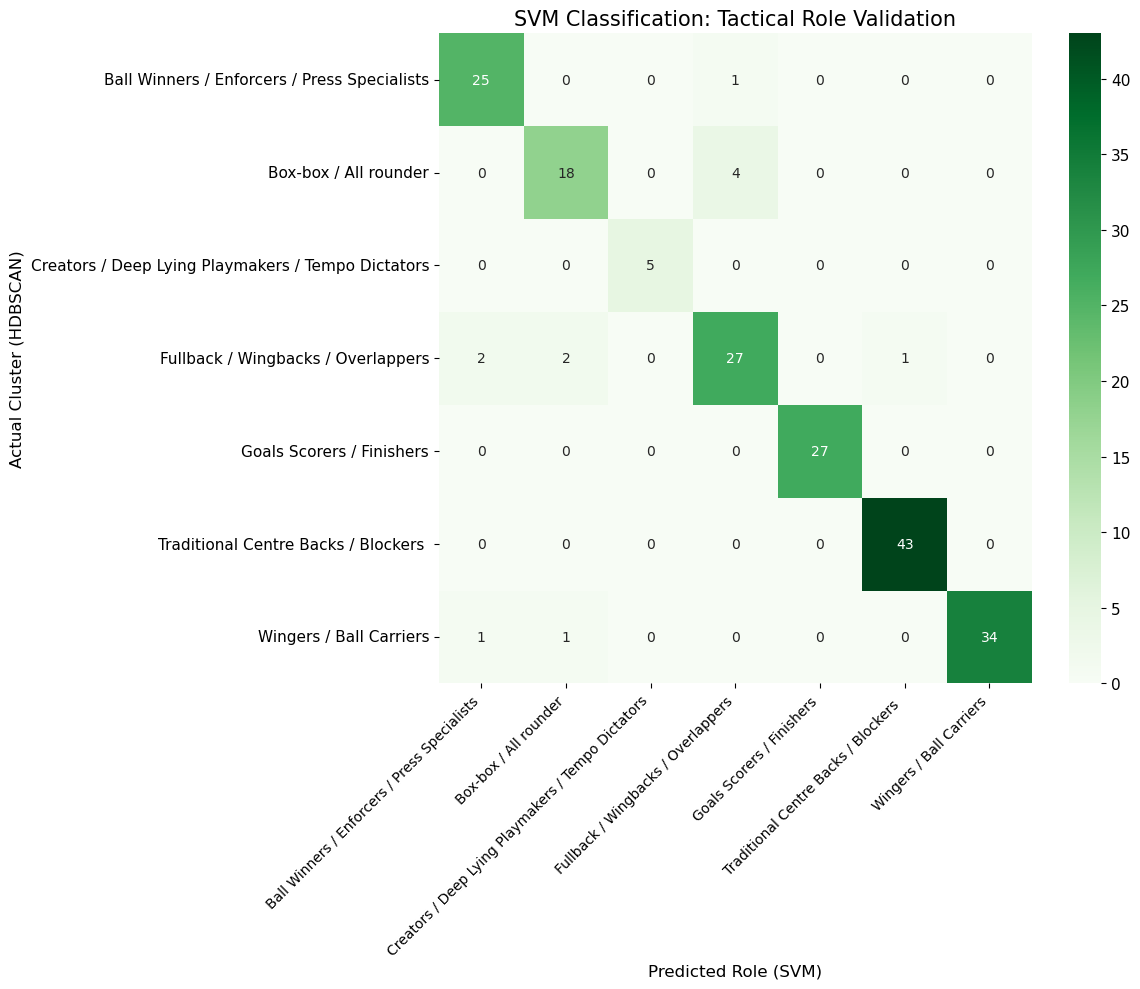

In [33]:
#SVM Nodel confusion matrix
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=position_encoder.classes_, 
            yticklabels=position_encoder.classes_)

plt.title('SVM Classification: Tactical Role Validation', fontsize=15)
plt.ylabel('Actual Cluster (HDBSCAN)', fontsize=12)
plt.xlabel('Predicted Role (SVM)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('svm_hdb_cm_5.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#rebuild hdbscan clusters with cluster centroids

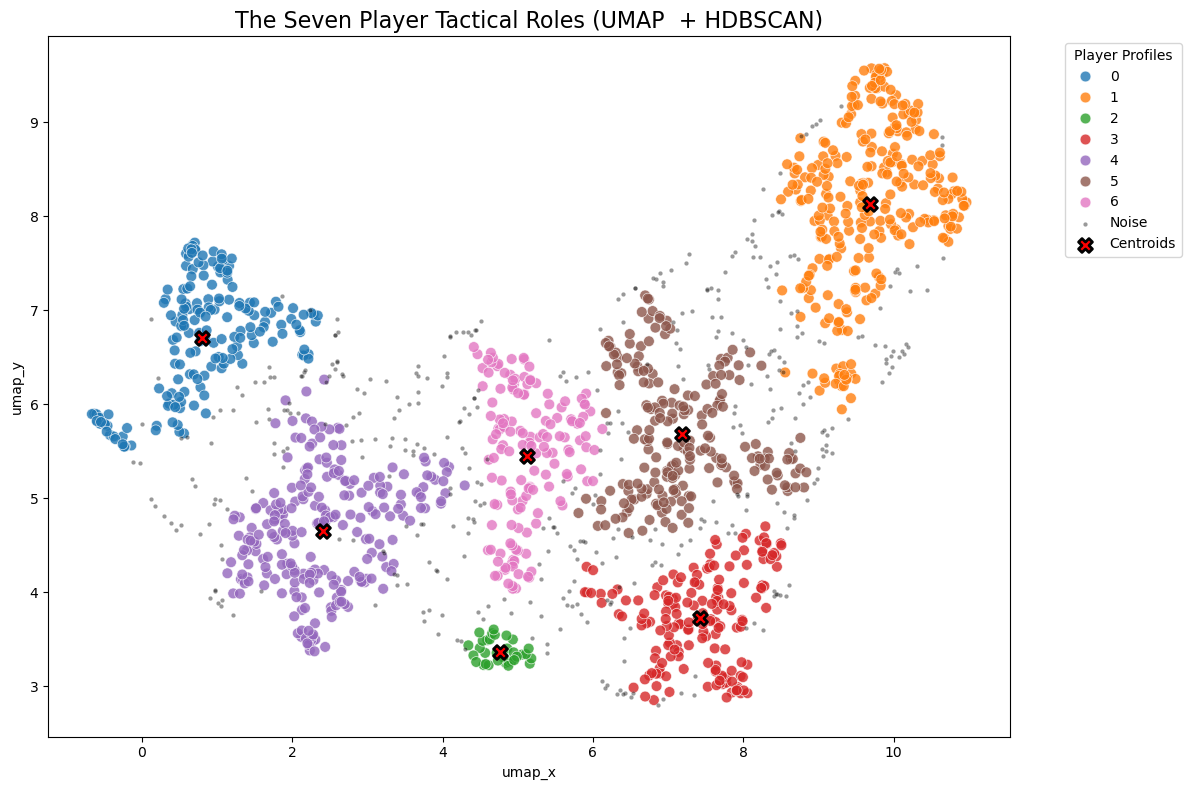

In [7]:
#sort by cluster labels
clustered_data = dataset_1.sort_values('tactical_roles_hdbscan')
#convert cluster labels to stings for coloring clusters by labels
clustered_data['Cluster_Label'] = clustered_data['tactical_roles_hdbscan'].astype(str)

noise_data = dataset[dataset['tactical_roles_hdbscan'] == -1]
#define cluster centroids
centroids = clustered_data.groupby('tactical_roles_hdbscan')[['umap_x', 'umap_y']].mean().reset_index()

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=clustered_data, 
    x='umap_x', y='umap_y', 
    hue='Cluster_Label', 
    palette='tab10', 
    s=60, alpha=0.8,
    edgecolor='white', linewidth=0.5)

sns.scatterplot(
    data=noise_data, 
    x='umap_x', y='umap_y', 
    color='black', s=10, alpha=0.4, label='Noise')

plt.scatter(
    centroids['umap_x'], centroids['umap_y'], 
    marker='X', s=100, color='red', 
    edgecolors='black', linewidth=2, label='Centroids')


plt.title('The Seven Player Tactical Roles (UMAP  + HDBSCAN)', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Player Profiles")
plt.tight_layout()
plt.show()

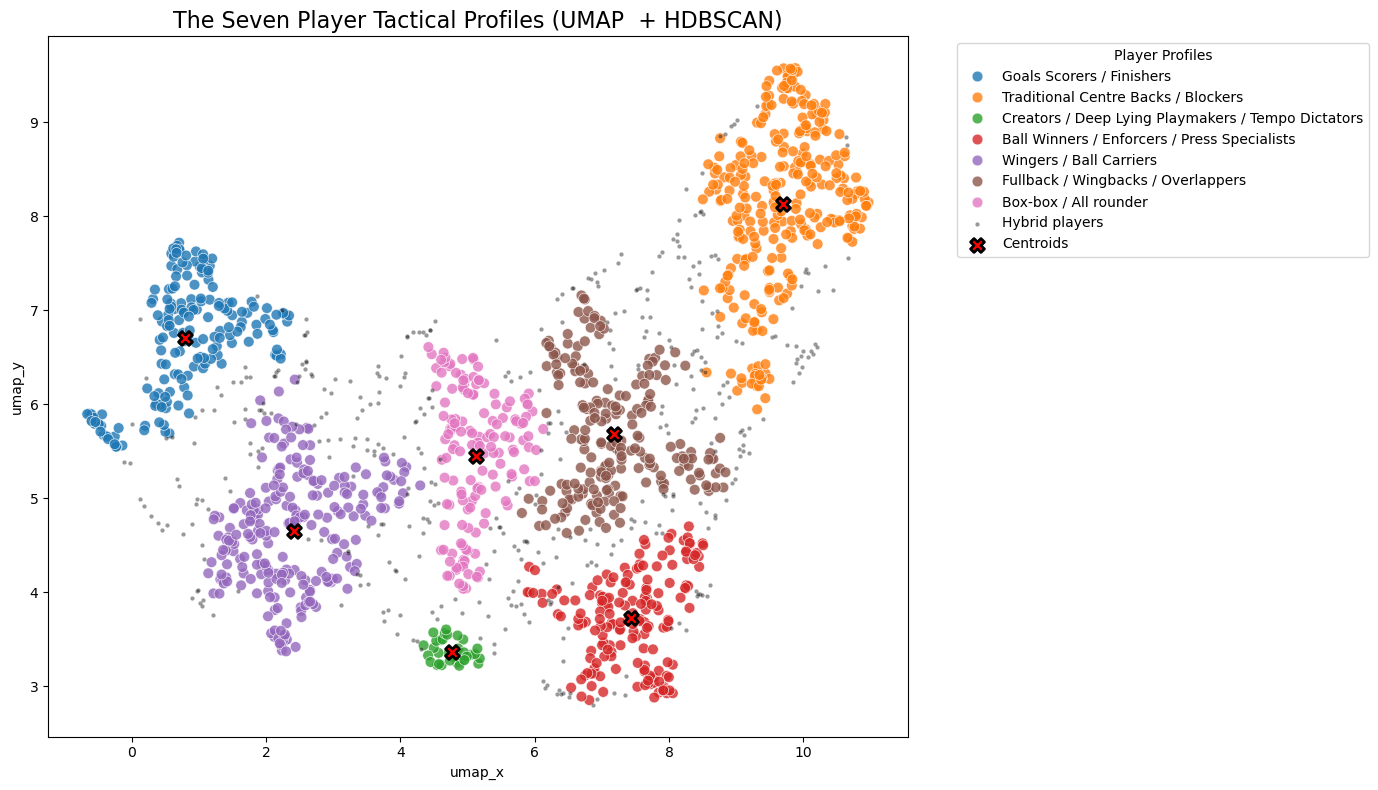

In [8]:
#cluster name mapping based on analysis
cluster_names = {
    '0': 'Goals Scorers / Finishers',
    '1': 'Traditional Centre Backs / Blockers',
    '2': 'Creators / Deep Lying Playmakers / Tempo Dictators',
    '3': 'Ball Winners / Enforcers / Press Specialists',
    '4': 'Wingers / Ball Carriers',
    '5': 'Fullback / Wingbacks / Overlappers',
    '6': 'Box-box / All rounder'}


clustered_data['Cluster_Label'] = clustered_data['tactical_roles_hdbscan'].astype(str).map(cluster_names).fillna('Hybrid players')
        
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=clustered_data, 
    x='umap_x', y='umap_y', 
    hue='Cluster_Label', 
    palette='tab10', 
    s=60, alpha=0.8,
    edgecolor='white', linewidth=0.5)

sns.scatterplot(
    data=noise_data, 
    x='umap_x', y='umap_y', 
    color='black', s=10, alpha=0.4, label='Hybrid players')

plt.scatter(
    centroids['umap_x'], centroids['umap_y'], 
    marker='X', s=100, color='red', 
    edgecolors='black', linewidth=2, label='Centroids')


plt.title('The Seven Player Tactical Profiles (UMAP  + HDBSCAN)', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Player Profiles")
plt.tight_layout()
plt.show()

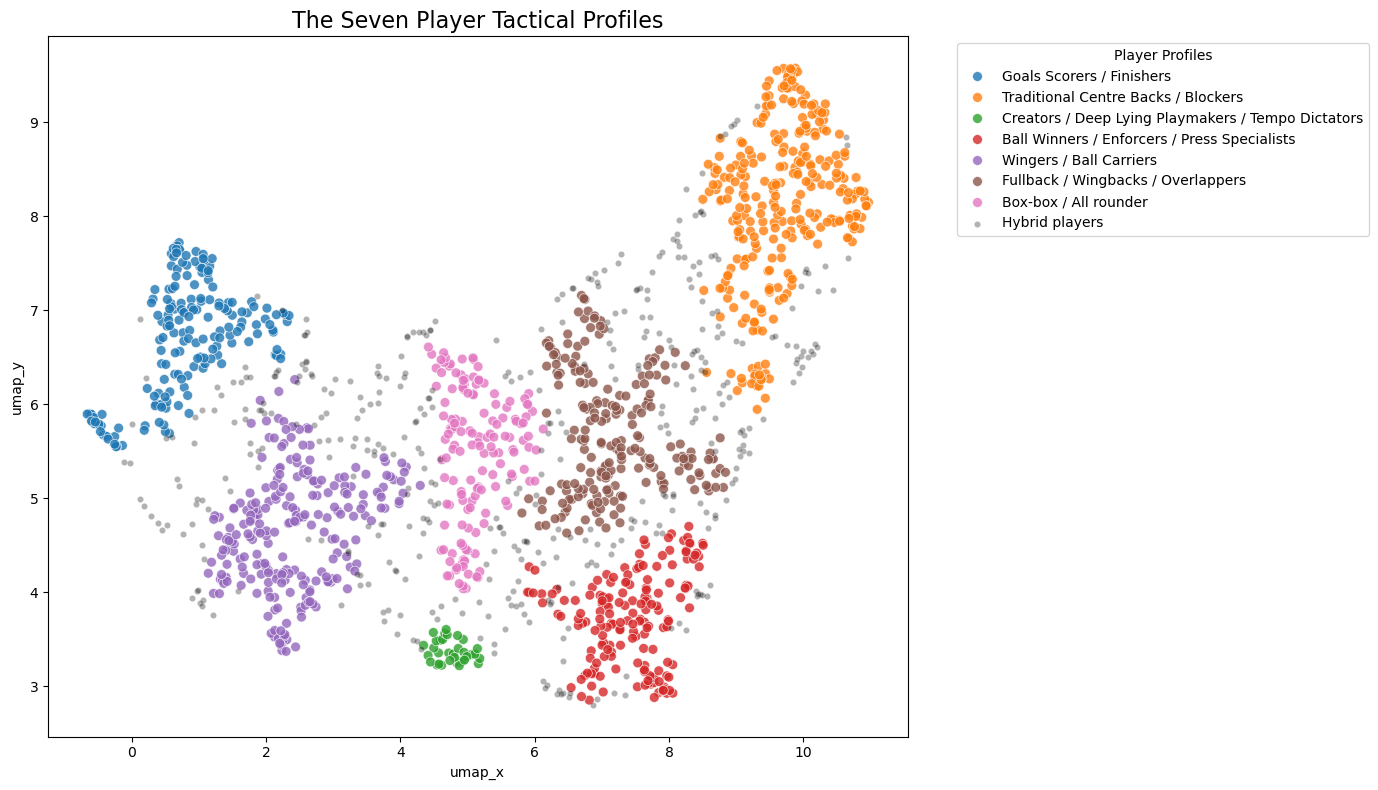

In [21]:
#cluster name mapping based on analysis
cluster_names = {
    '0': 'Goals Scorers / Finishers',
    '1': 'Traditional Centre Backs / Blockers',
    '2': 'Creators / Deep Lying Playmakers / Tempo Dictators',
    '3': 'Ball Winners / Enforcers / Press Specialists',
    '4': 'Wingers / Ball Carriers',
    '5': 'Fullback / Wingbacks / Overlappers',
    '6': 'Box-box / All rounder'}


clustered_data['Cluster_Label'] = clustered_data['tactical_roles_hdbscan'].astype(str).map(cluster_names).fillna('Hybrid players')
        
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=clustered_data, 
    x='umap_x', y='umap_y', 
    hue='Cluster_Label', 
    palette='tab10', 
    s=50, alpha=0.8,
    edgecolor='white', linewidth=0.5)

sns.scatterplot(
    data=noise_data, 
    x='umap_x', y='umap_y', 
    color='black', s=20, alpha=0.3, label='Hybrid players')


plt.title('The Seven Player Tactical Profiles', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Player Profiles")
plt.tight_layout()
plt.savefig('streamlit_hdb_clusters.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#SHAP ANALYSIS

In [18]:
import shap
import matplotlib
matplotlib.rcParams['ytick.labelsize'] = 11

#shap explainer for LR model using training data
lr_explainer = shap.LinearExplainer(lr_model, X_combined)

#find shap values per player and coverts to 2D array needed by SHAP
shap_values_per_player = []
for i in range(len(X_combined)):
    sv = lr_explainer.shap_values(X_combined[i].reshape(1, -1))
    shap_values_per_player.append(sv)

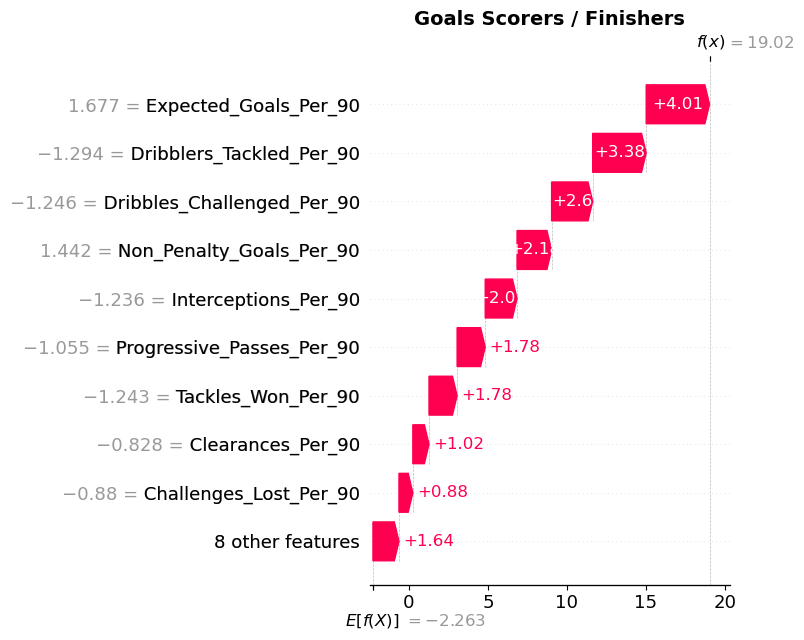

In [19]:
#Goals Scorers / Finishers

#encodes goal scorer cluster
cluster_encode = position_encoder.transform(['Goals Scorers / Finishers'])[0]

#stores the index of all goal scorers
cluster_indices = np.where(y_combined == cluster_encode)[0]

#averages the SHAP values of all players in the goal scorer cluster
cluster_shap = np.mean([shap_values_per_player[i][0, :, cluster_encode] for i in cluster_indices], axis=0)

#SHAP plot
shap.plots.waterfall(shap.Explanation(
    values=cluster_shap,
    base_values=lr_explainer.expected_value[cluster_encode],
    data=X_combined[cluster_indices].mean(axis=0),
    feature_names=features
), show=False)
plt.title("Goals Scorers / Finishers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_goals_scorers.png', dpi=300, bbox_inches='tight')
plt.show()

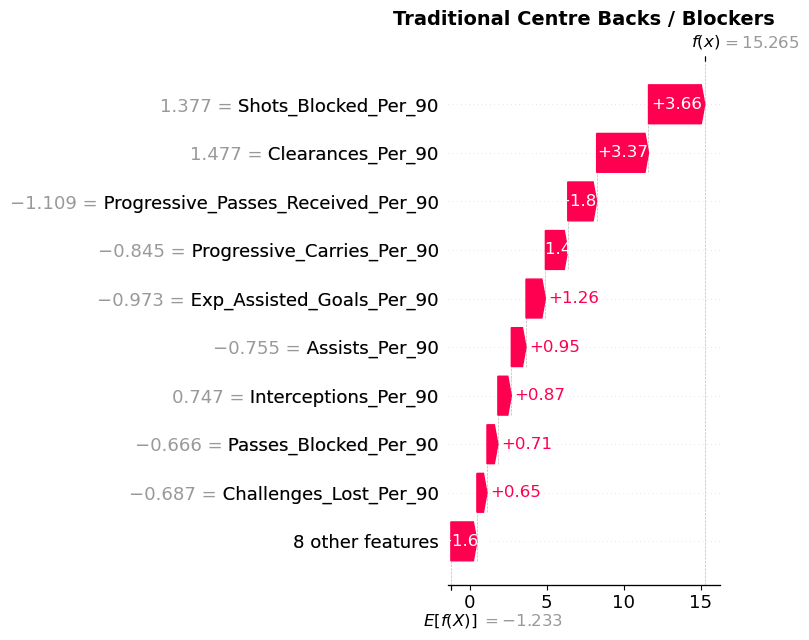

In [20]:
#Traditional Centre Backs / Blockers

cluster_encode = position_encoder.transform(['Traditional Centre Backs / Blockers '])[0]

cluster_indices = np.where(y_combined == cluster_encode)[0]
cluster_shap = np.mean([shap_values_per_player[i][0, :, cluster_encode] for i in cluster_indices], axis=0)

shap.plots.waterfall(shap.Explanation(
    values=cluster_shap,
    base_values=lr_explainer.expected_value[cluster_encode],
    data=X_combined[cluster_indices].mean(axis=0),
    feature_names=features
), show=False)
plt.title("Traditional Centre Backs / Blockers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_centre_backs.png', dpi=300, bbox_inches='tight')
plt.show()

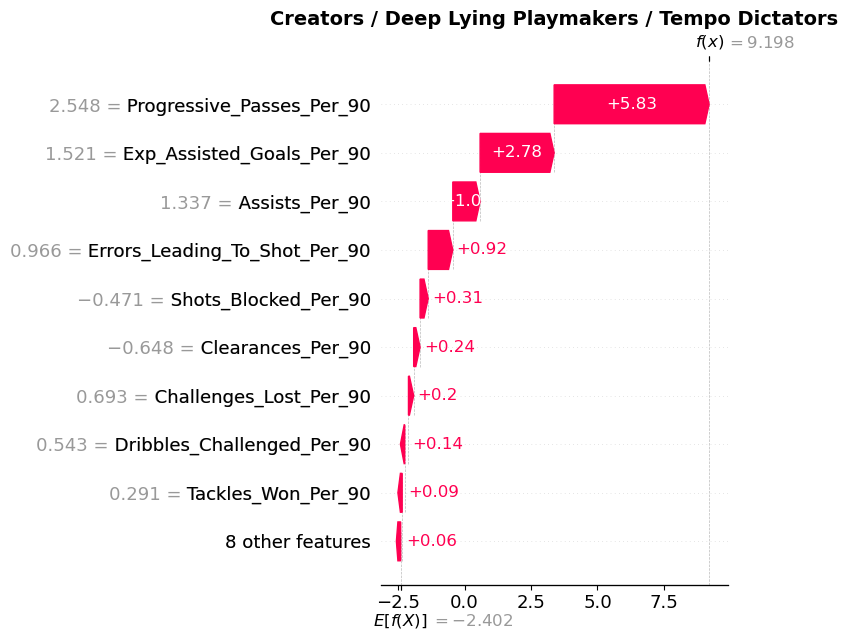

In [21]:
#Creators / Deep Lying Playmakers / Tempo Dictators

cluster_encode = position_encoder.transform(['Creators / Deep Lying Playmakers / Tempo Dictators'])[0]

cluster_indices = np.where(y_combined == cluster_encode)[0]

cluster_shap = np.mean([shap_values_per_player[i][0, :, cluster_encode] for i in cluster_indices], axis=0)

shap.plots.waterfall(shap.Explanation(
    values=cluster_shap,
    base_values=lr_explainer.expected_value[cluster_encode],
    data=X_combined[cluster_indices].mean(axis=0),
    feature_names=features
), show=False)
plt.title("Creators / Deep Lying Playmakers / Tempo Dictators", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_creators_dlp.png', dpi=300, bbox_inches='tight')
plt.show()

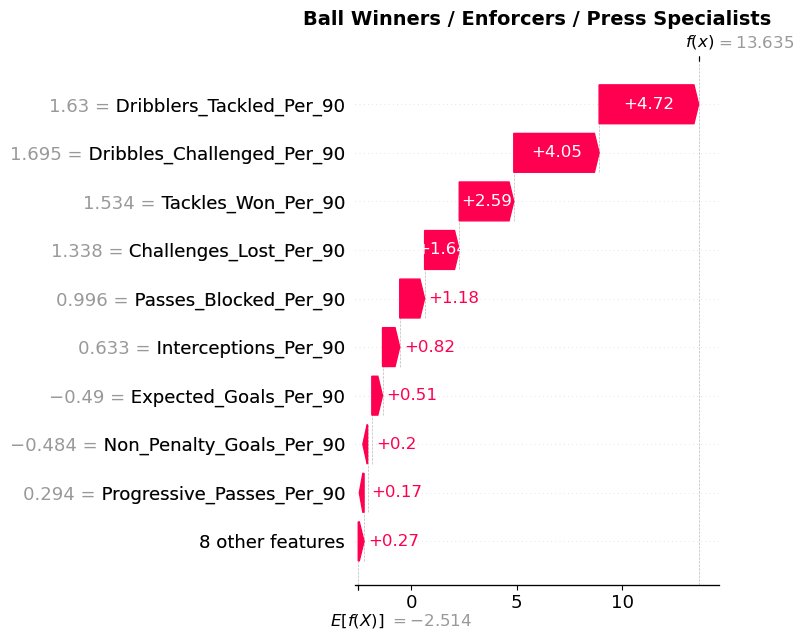

In [22]:
#Ball Winners / Enforcers / Press Specialists

cluster_encode = position_encoder.transform(['Ball Winners / Enforcers / Press Specialists'])[0]

cluster_indices = np.where(y_combined == cluster_encode)[0]

cluster_shap = np.mean([shap_values_per_player[i][0, :, cluster_encode] for i in cluster_indices], axis=0)
shap.plots.waterfall(shap.Explanation(
    values=cluster_shap,
    base_values=lr_explainer.expected_value[cluster_encode],
    data=X_combined[cluster_indices].mean(axis=0),
    feature_names=features
), show=False)
plt.title("Ball Winners / Enforcers / Press Specialists", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_ball_winners.png', dpi=300, bbox_inches='tight')
plt.show()

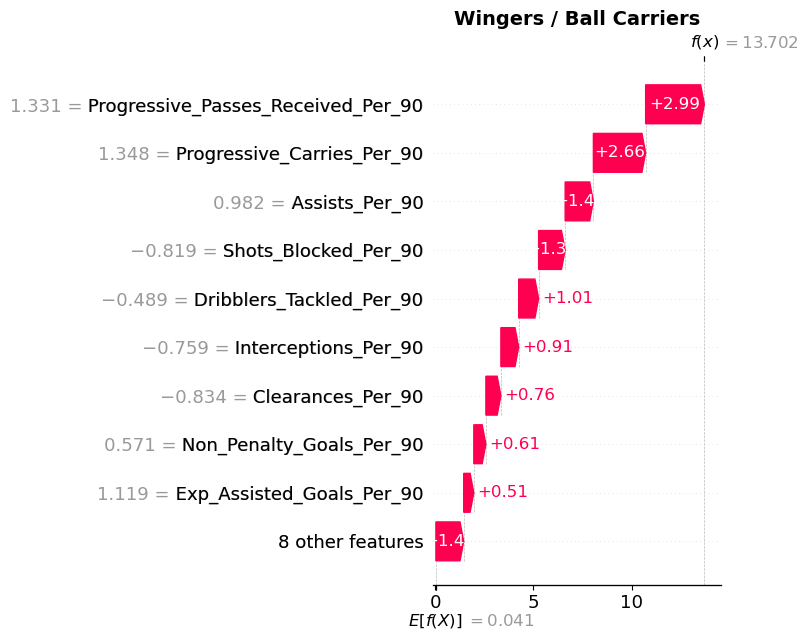

In [23]:
#Wingers / Ball Carriers

cluster_encode = position_encoder.transform(['Wingers / Ball Carriers'])[0]
cluster_indices = np.where(y_combined == cluster_encode)[0]


cluster_shap = np.mean([shap_values_per_player[i][0, :, cluster_encode] for i in cluster_indices], axis=0)
shap.plots.waterfall(shap.Explanation(
    values=cluster_shap,
    base_values=lr_explainer.expected_value[cluster_encode],
    data=X_combined[cluster_indices].mean(axis=0),
    feature_names=features
), show=False)
plt.title("Wingers / Ball Carriers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_wingers.png', dpi=300, bbox_inches='tight')
plt.show()

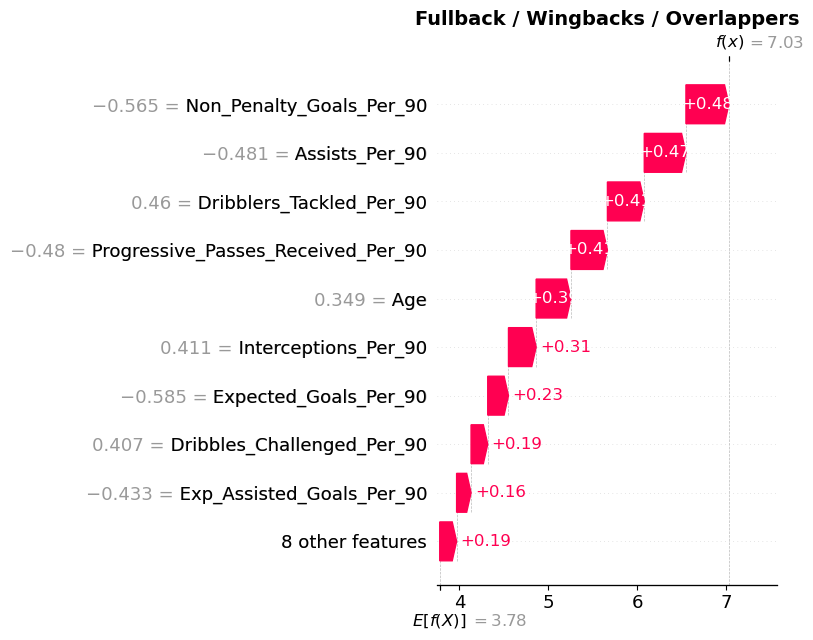

In [24]:
#Fullback / Wingbacks / Overlappers

cluster_encode = position_encoder.transform(['Fullback / Wingbacks / Overlappers'])[0]

cluster_indices = np.where(y_combined == cluster_encode)[0]

cluster_shap = np.mean([shap_values_per_player[i][0, :, cluster_encode] for i in cluster_indices], axis=0)
shap.plots.waterfall(shap.Explanation(
    values=cluster_shap,
    base_values=lr_explainer.expected_value[cluster_encode],
    data=X_combined[cluster_indices].mean(axis=0),
    feature_names=features
), show=False)
plt.title("Fullback / Wingbacks / Overlappers", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_fullbacks.png', dpi=300, bbox_inches='tight')
plt.show()

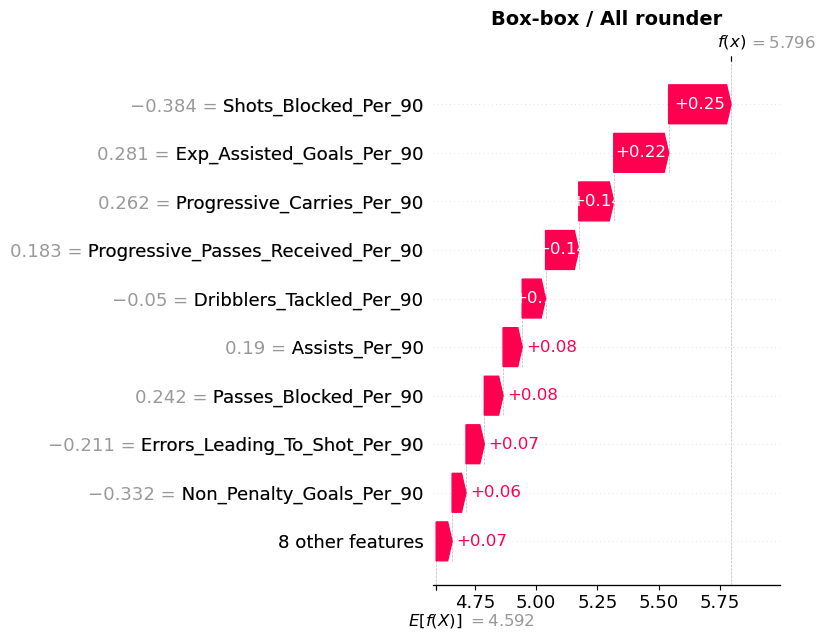

In [25]:
#Box-box / All rounder

cluster_encode = position_encoder.transform(['Box-box / All rounder'])[0]

cluster_indices = np.where(y_combined == cluster_encode)[0]

cluster_shap = np.mean([shap_values_per_player[i][0, :, cluster_encode] for i in cluster_indices], axis=0)
shap.plots.waterfall(shap.Explanation(
    values=cluster_shap,
    base_values=lr_explainer.expected_value[cluster_encode],
    data=X_combined[cluster_indices].mean(axis=0),
    feature_names=features
), show=False)
plt.title("Box-box / All rounder", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_box_box.png', dpi=300, bbox_inches='tight')
plt.show()

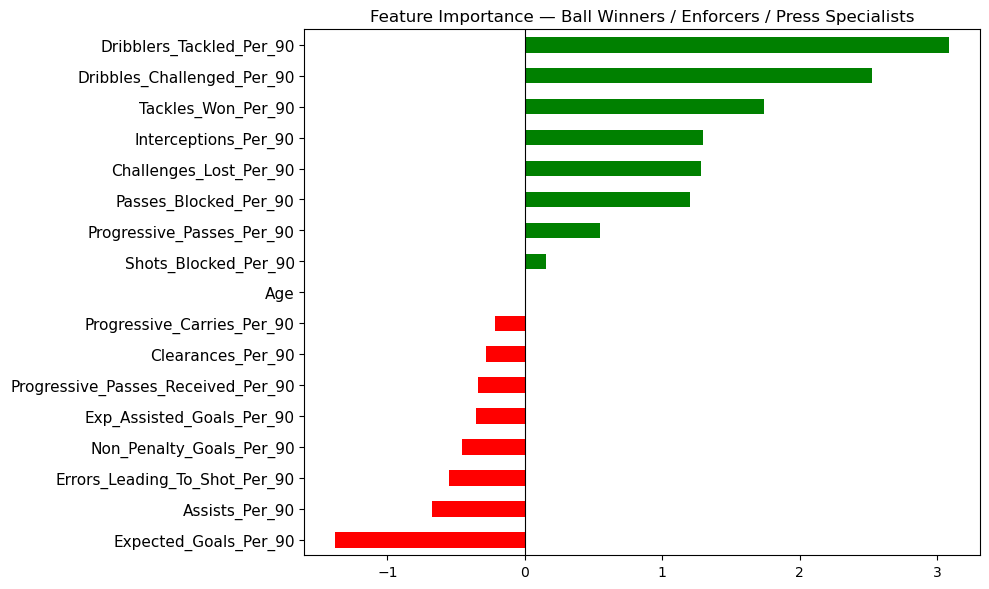

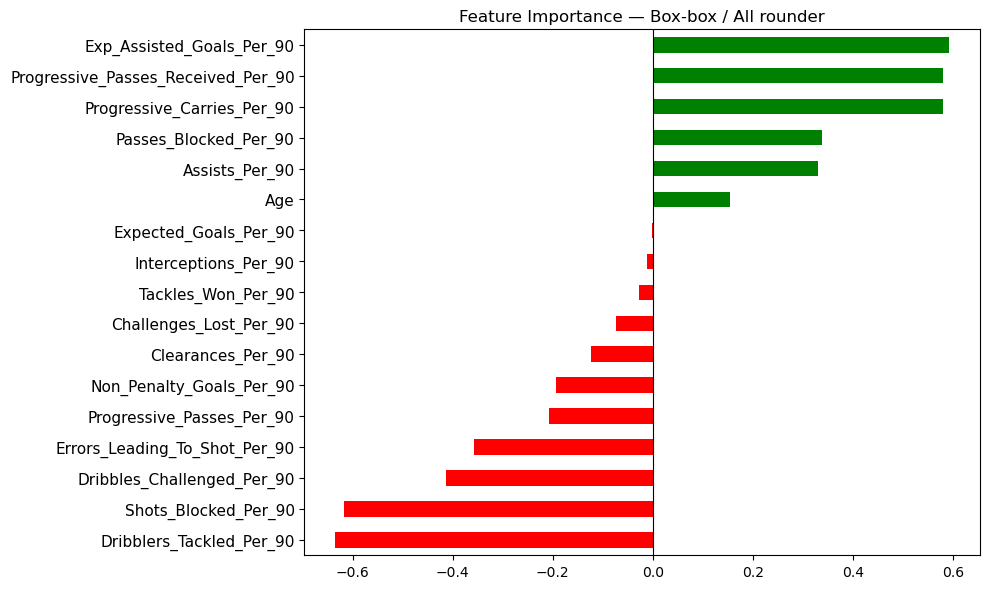

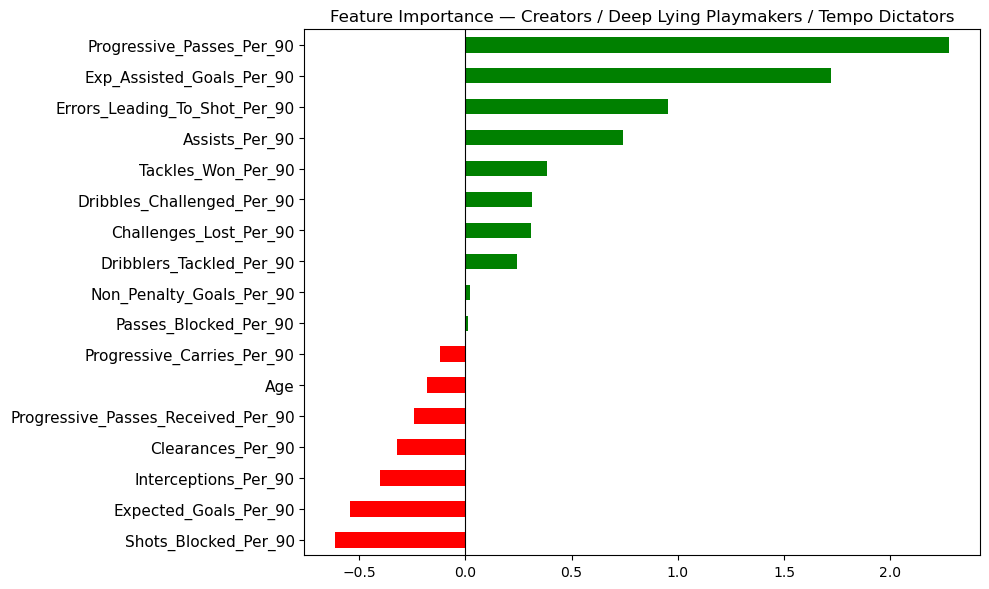

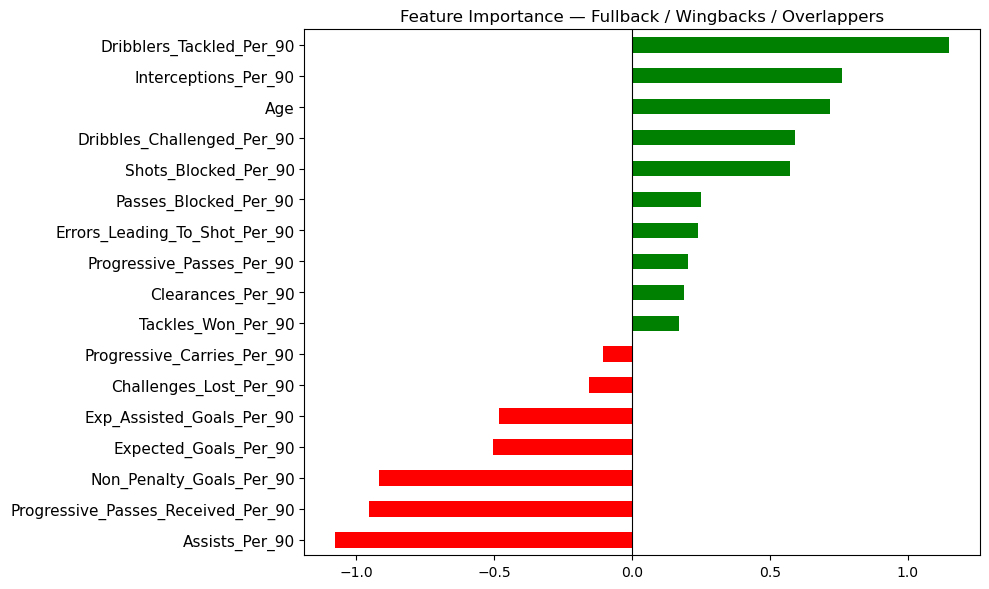

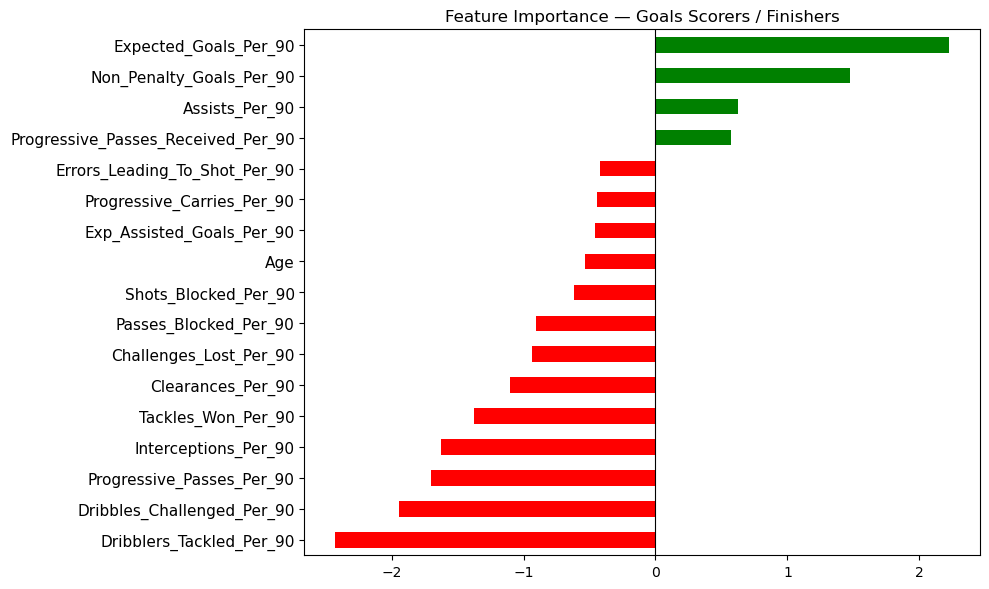

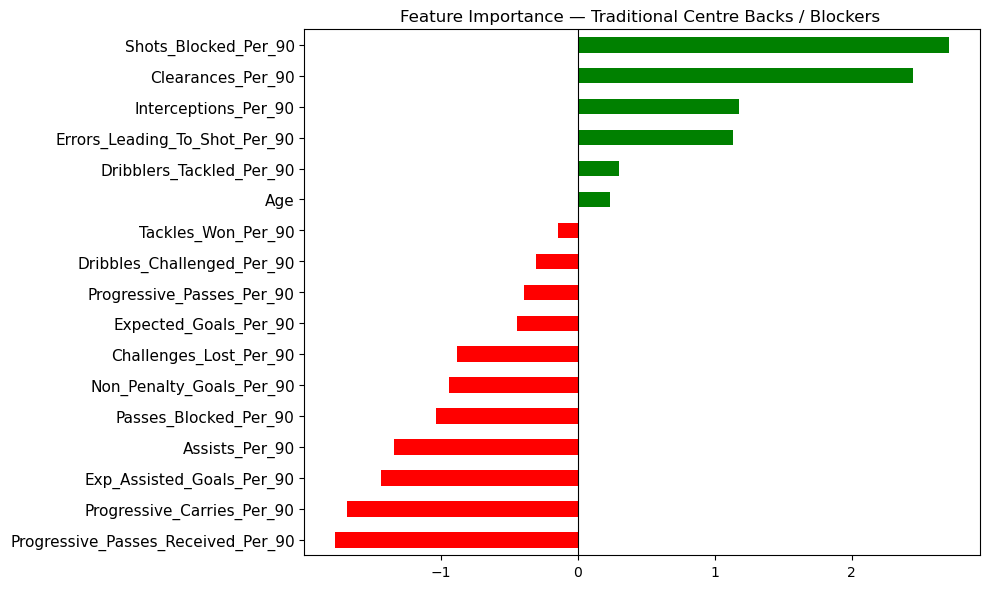

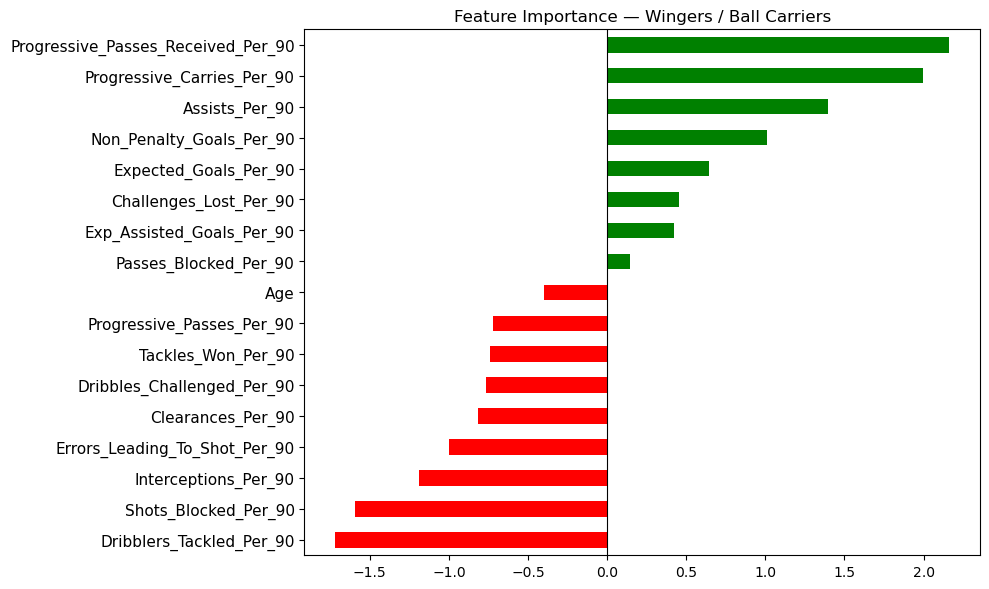

In [26]:
#LR model features importance 
coef_df = pd.DataFrame(
    lr_model.coef_, 
    columns=features, 
    index=position_encoder.classes_
)

for role in position_encoder.classes_:
    coef_df.loc[role].sort_values().plot(kind='barh', figsize=(10, 6), color=['red' if x < 0 else 'green' for x in coef_df.loc[role].sort_values()])
    plt.title(f"Feature Importance — {role}")
    plt.axvline(0, color='black', linewidth=0.8)
    plt.tight_layout()
    plt.savefig('lr_coeff.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
#similarity search

In [9]:
#create a new scaler, X_scaled which is all the players in the main dataset
from sklearn.preprocessing import StandardScaler
scaler_full = StandardScaler()
X_1 = dataset[features].values
X_scaled = scaler_full.fit_transform(X_1)

In [28]:
aaa=np.array(X_scaled)
print(aaa.shape)

(1706, 17)


In [29]:
print(dataset.shape)

(1706, 55)


In [11]:
from sklearn.metrics.pairwise import cosine_similarity


In [15]:

role_names = {
   0: 'Goals Scorers / Finishers',
    1: 'Traditional Centre Backs / Blockers',
    2: 'Creators / Deep Lying Playmakers / Tempo Dictators',
    3: 'Ball Winners / Enforcers / Press Specialists',
    4: 'Wingers / Ball Carriers',
    5: 'Fullback / Wingbacks / Overlappers',
    6: 'Box-box / All rounder',
    -1: 'Hybrid Players'}

#convert numerical currency values to easy to read strings
def format_currency(value):
    if value >= 1_000_000:
        return f"€{value / 1_000_000:.1f}M"
    else:
        return f"€{value / 1_000:.0f}K"

#similar players function based on cosine similarity

def find_similar_players(player_name, top_n=10):
    dataset_sim = dataset.reset_index(drop=True)

    #use uppercase here as player names are stored in uppercase in the dataset
    player_name_upper = player_name.upper()
    
    if player_name_upper not in dataset_sim['name_key_1'].values:
        return f"Player '{player_name}' not found."
        
    #finds the searched player in the dataset
    target_idx = dataset_sim[dataset_sim['name_key_1'] == player_name_upper].index[0]

    #find the players hdb cluster label
    target_cluster = dataset_sim.loc[target_idx, 'tactical_roles_hdbscan']

    #find the players scaled features
    target_stats = X_scaled[target_idx].reshape(1, -1)
    
    #calculate the player's cosine similarity
    similarities = cosine_similarity(target_stats, X_scaled).flatten()
    dataset_sim['Similarity_Score'] = (similarities * 100).round(2)
    
    recommendations = dataset_sim[
    (dataset_sim['name_key_1'] != player_name_upper) & 
    (dataset_sim['tactical_roles_hdbscan'] == target_cluster)].sort_values('Similarity_Score', ascending=False).head(top_n).copy()
    
    recommendations['Tactical_Role_1'] = recommendations['tactical_roles_hdbscan'].map(role_names)
    
    recommendations['Market_Value'] = recommendations['player_market_value_euro'].apply(format_currency)
    
    return recommendations[['name_key_1', 'current_club', 'Age', 'Market_Value', 
                            'Tactical_Role_1', 'Similarity_Score']]

print(find_similar_players("vinicius junior"))

           name_key_1         current_club  Age Market_Value Tactical_Role_1  \
617     HARVEY BARNES     Newcastle United   26       €35.0M  Hybrid Players   
31    ADEMOLA LOOKMAN   Atlético de Madrid   26       €60.0M  Hybrid Players   
919      LAMINE YAMAL         FC Barcelona   17      €200.0M  Hybrid Players   
1174    MOHAMED SALAH         Liverpool FC   32       €50.0M  Hybrid Players   
866     KARIM ADEYEMI    Borussia Dortmund   22       €45.0M  Hybrid Players   
246   BRADLEY BARCOLA  Paris Saint-Germain   21       €70.0M  Hybrid Players   
1281    OMAR MARMOUSH      Manchester City   25       €75.0M  Hybrid Players   
1292  OUSMANE DEMBELE  Paris Saint-Germain   27       €90.0M  Hybrid Players   
1081  MASON GREENWOOD  Olympique Marseille   22       €40.0M  Hybrid Players   
262       BUKAYO SAKA           Arsenal FC   22      €150.0M  Hybrid Players   

      Similarity_Score  
617              93.32  
31               92.43  
919              87.85  
1174             86

In [ ]:
#Squad Gap Analysis

In [23]:
def squad_gap_analysis(team_name):
    dataset_gap = dataset.reset_index(drop=True)
    
    team_name_upper = team_name.upper()
    
    if team_name_upper not in dataset_gap['current_club'].str.upper().values:
        return f"Team '{team_name}' not found, please try searching team name in full"
    
    #filter to input team only
    team_players = dataset_gap[dataset_gap['current_club'].str.upper() == team_name_upper].copy()
    
    #map cluster numbers to role names
    team_players['Tactical_Role'] = team_players['tactical_roles_hdbscan'].map(role_names)
    
    #count players per role
    role_counts = team_players['Tactical_Role'].value_counts().reset_index()
    role_counts.columns = ['Tactical_Role', 'Player_Count']
    
    #ensure all 8 roles appear even if count is 0
    all_roles = pd.DataFrame({'Tactical_Role': list(role_names.values())})
    role_counts = all_roles.merge(role_counts, on='Tactical_Role', how='left').fillna(0)
    role_counts['Player_Count'] = role_counts['Player_Count'].astype(int)
    role_counts = role_counts.sort_values('Player_Count', ascending=False).reset_index(drop=True)
    
    total = role_counts['Player_Count'].sum()
    
    print(f"\n Squad Profile — {team_name.title()}")
    print(f" Total Players: {total}\n")
    
    return role_counts

print(squad_gap_analysis("chelsea fc"))


 Squad Profile — Chelsea Fc
 Total Players: 19

                                       Tactical_Role  Player_Count
0                Traditional Centre Backs / Blockers             6
1                            Wingers / Ball Carriers             5
2       Ball Winners / Enforcers / Press Specialists             3
3                 Fullback / Wingbacks / Overlappers             2
4  Creators / Deep Lying Playmakers / Tempo Dicta...             1
5                          Goals Scorers / Finishers             1
6                                     Hybrid Players             1
7                              Box-box / All rounder             0
